##**Air Passanger Case Study**
In this dataset, we will talk about the time series analysis where, we will forecast the no.of passengers who are going to travel in next few yrs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/AirPassengers.csv')

In [3]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.tail()

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [5]:
df.isnull().sum()

,0
Month,0
#Passengers,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [8]:
df['Month'] = pd.to_datetime(df['Month'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [10]:
df.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [11]:
df.set_index('Month', inplace = True)

In [12]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


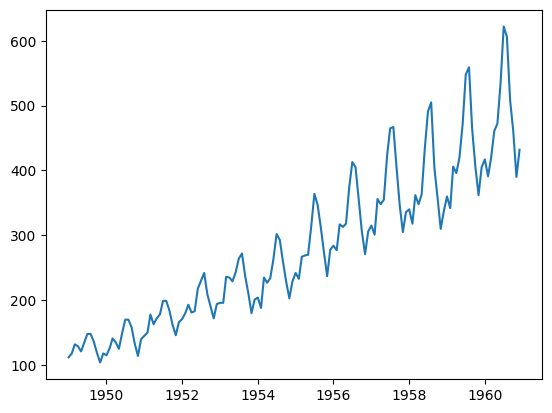

In [13]:
plt.plot(df['#Passengers'])

**Insight**
* We have trend (positive upward trend)
* We have seasonality (repeating wave lines like pattern every interval of time)
* Residuals - The random fluctuations or irregular variations can be the reason for residuals

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [15]:
decompose = seasonal_decompose(df['#Passengers'])

Figure(640x480)


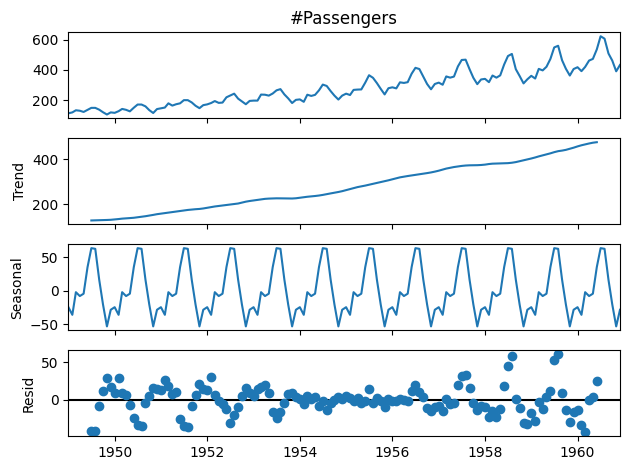

In [16]:
print(decompose.plot())

###**ADF TEST**
Agumented Dicky Fuller Test to check where data is stationary or not

In [17]:
from statsmodels.tsa.stattools import adfuller

In [18]:
result = adfuller(df['#Passengers'])

In [19]:
result

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [20]:
pVal = result[1]
if pVal <= 0.05:
  print('Data is stationary')
else:
  print('Data is not stationary')

Data is not stationary


To make the data stationary:

In [21]:
rollingMean = df.rolling(window = 12).mean()

In [22]:
rollingStd = df.rolling(window=12).std()

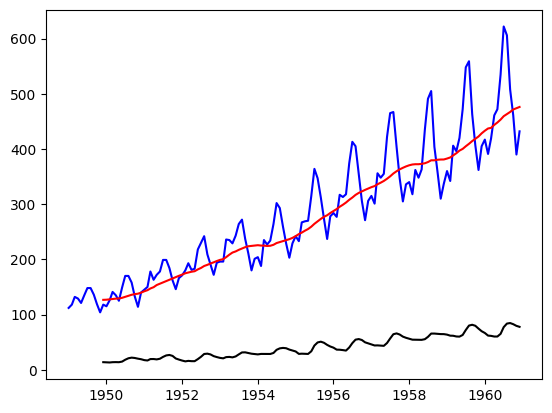

In [23]:
plt.plot(df, color='blue')
plt.plot(rollingMean, color='red')
plt.plot(rollingStd, color='black')
plt.show()

###**Log Transformation**
* It compresses the large value more than small ones, which reduces the gap betn the large data

In [24]:
log_df = np.log(df)
log_df

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [25]:
rollingMean = log_df.rolling(window = 12).mean()
rollingStd = log_df.rolling(window=12).std()

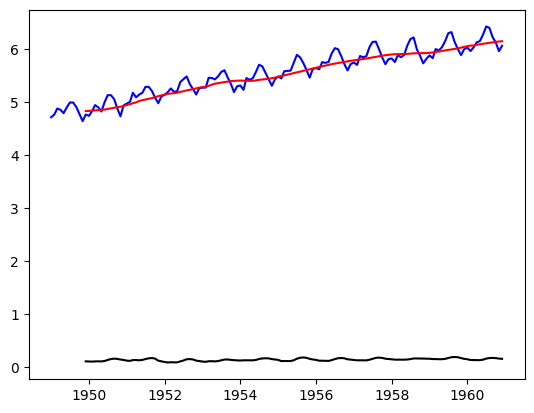

In [26]:
plt.plot(log_df, color='blue')
plt.plot(rollingMean, color='red')
plt.plot(rollingStd, color='black')
plt.show()

**Differencing**

diff = current val - previous val

In [29]:
diff_data = log_df.diff()
diff_data

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
...,...
1960-08-01,-0.026060
1960-09-01,-0.176399
1960-10-01,-0.097083


In [30]:
diff_data.dropna(inplace=True)

In [31]:
diff_data

,#Passengers
Month,
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
1949-06-01,0.109484
...,...
1960-08-01,-0.026060
1960-09-01,-0.176399
1960-10-01,-0.097083


In [32]:
rollingMean = diff_data.rolling(window = 12).mean()
rollingStd = diff_data.rolling(window=12).std()

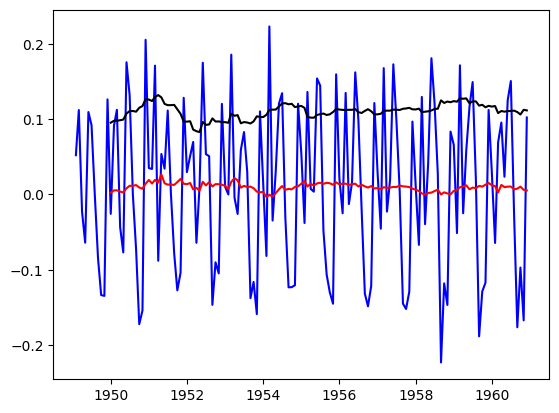

In [33]:
plt.plot(diff_data, color='blue')
plt.plot(rollingMean, color='red')
plt.plot(rollingStd, color='black')
plt.show()

In [34]:
result = adfuller(diff_data['#Passengers'])
print(result[1])

0.07112054815086184


In [35]:
pVal = result[1]
if pVal <= 0.05:
  print('Data is stationary')
else:
  print('Data is not stationary')

Data is not stationary


**Shift**

In [39]:
diff_data = log_df.diff()

###**Sarimax**

In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [44]:
s_model = SARIMAX(train, order=(5,1,4), seasonal_order=(5,1,4,12))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
